# Predicting Loan Default Risk and Identifying Key Drivers of Credit Risk

An undisclosed banking entity has provided a dataset containing customer data that is focused on lending and default.  Financial institutions must assess borrower risk before approving loans.  This contract requests that I analyze the data and answer questions about customer outcomes.  The analytics objectives are to:

1. Identify key drivers associated with loan default.
2. Build predictive models to estimate the probability of default.
3. Develop a risk-based framework to support lending decisions.

## Business Understanding
Problem definition

Why default prediction matters

Stakeholders (lenders, risk teams)

## Data Understanding

#### Library Load

In [60]:
# ===============================
# Standard Library
# ===============================
import os
import warnings

# ===============================
# Data Manipulation
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ===============================
# Scikit-Learn
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# ===============================
# Settings
# ===============================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Converts Scientific Notation to rational number. 
#pd.options.display.float_format = '{:,.2f}'.format # Toggle Comments to implement or not

# --- Global styling ---
sns.set_theme(
    style="whitegrid",     # clean background
    context="talk",        # larger readable fonts
    palette="deep"
)





#### Functions

In [61]:
# Outlier Check Function
def iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)]

In [62]:
# Currency Conversion Fucntion
def currency_to_float(series):
    return (
        series
        .str.replace(r'[^\d.]', '', regex=True)
        .pipe(pd.to_numeric, errors='coerce')
    )

In [63]:
# Function for making aesthetic plots
def plot_professional_default_rate(df, feature, title=None):
    # Calculate rates
    summary = df.groupby(feature)["Current_loan_status"].value_counts(normalize=True).unstack()["DEFAULT"]
    summary = summary.sort_values(ascending=False)
    
    # 1. Setup Figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    # 2. Use a sophisticated color palette (e.g., 'mako' or custom hex)
    colors = ['#1a434e' if (x < summary.max()) else '#e74c3c' for x in summary]
    
    sns.barplot(x=summary.index, y=summary.values, palette=colors, ax=ax)
    
    # 3. Enhance Typography and Labels
    ax.set_title(title or f"Default Risk by {feature.replace('_', ' ').title()}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_ylabel("Probability of Default", fontsize=12, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    # 4. Format Y-axis as Percentage
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 5. Remove "Chart Junk" (Spines)
    sns.despine(left=True, bottom=False)
    
    # 6. Add Data Labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [93]:
def plot_target_distribution(df, target_col):
    """Professional plot for the Target Variable distribution."""
    counts = df[target_col].value_counts(normalize=True)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ['#1a434e', '#e74c3c'] # Professional Navy and Risk Red
    
    sns.barplot(x=counts.index, y=counts.values, palette=colors, ax=ax)
    
    # Labeling
    ax.set_title("Target Variable Distribution (Class Balance)", fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel("Proportion of Portfolio", fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Add percentage labels on top
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    sns.despine()
    plt.show()


#### Load dataset

In [64]:
# Project root (adjust if needed)
PROJECT_ROOT = r"A:\Personal Files\Career Folder\Data_Science\data-science-toolbox"
DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "datasets",
    "raw",
    "Loan_Dataset",
    "LoanDataset.csv"
)

# Load the dataset using pandas read_csv. 
data = pd.read_csv(DATA_PATH)

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (32586, 13)


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


An initial assessment of the data shows a thirteen features over 32,586 observations.  

#### Variable descriptions

From the documentation (https://www.kaggle.com/datasets/prakashraushan/loan-dataset), we have been given the details of the dataset consisting of the following columns:

- customer_id: Unique identifier for each customer
- customer_age: Age of the customer
- customer_income: Annual income of the customer
- home_ownership: Home ownership status (e.g., RENT, OWN, MORTGAGE)
- employment_duration: Duration of employment in months
- loan_intent: Purpose of the loan (e.g., PERSONAL, EDUCATION, MEDICAL, VENTURE)
- loan_grade: Grade assigned to the loan
- loan_amnt: Loan amount requested
- loan_int_rate: Interest rate of the loan
- term_years: Loan term in years
- historical_default: Indicates if the customer has a history of default (Y/N)
- cred_hist_length: Length of the customer's credit history in years
- Current_loan_status: Current status of the loan (DEFAULT, NO DEFAULT)

In [65]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB
None


In [66]:
data.isna().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

#### Initial observations

A preliminary exploratory data analysis review shows that the data possesses some gaps.  There are quite a few `NaN` values that need to be corrected because their existence is preventing the pythons describe from giving us meaningful information about the summary statistics of each column.  

There are some data points that do not make sense.  For example, the customer_age column has a min value of 3 and a max value of 144.  These values are atypical of a common loan account. We will explore the customerid format which is currently in float form (uncommon). We will also explore loan_amnt compared to loan intent.  We are looking for values of that are atypical of those lending cases.  For example, we would want to make sure home loans are not lower than a certain threshold.  The employment_duration column also contains some odd values that are worth looking into (0, 123).  We would also be interested in loan_int_rate and loan_intent.  Certain sectors of the economic lending have a range of normal values.  We would not come to expect that a student loan interest rate would be less than a mortgage.  I would like to investigate a relationship between customer_income and loan_amnt values that are mortgages.  There is almost certainly multicollinearity there and we would be intersted in exploring such cases.  

Recap.  Explore: 
- NaN value
- Odd values 
- relationships and multicollinearity

## Data Cleaning & Feature Engineering

#### Drop duplicates, features, then missing values

The `customer_id` has one last use before we drop it from our table--duplication verification.  Dataset integrity was evaluated using both entity-level (customer_id) and record-level duplication checks. Six customer IDs appeared multiple times in the dataset; however, inspection revealed that each duplicated pair contained identical values across all features and the target variable.

These records therefore represent data duplication rather than multiple loan applications. To prevent artificial inflation of sample size and bias in downstream statistical analysis and model training, duplicate rows were removed, retaining a single instance of each observation.

After removing the duplicates, the `customer_id` column was purged from our table.  Missing values were handled with care, feature-by-feature.  A brief description of what the decisioning was can be found in the code chunk notes in each cell.  

##### Duplicates

In [67]:
#Exact row duplicates
data.duplicated().sum()
data[data.duplicated()]

#Customer-level duplicates check
data[data['customer_id'].duplicated(keep=False)].sort_values('customer_id')
(data.groupby('customer_id').size().loc[lambda x: x > 1])
data[data.duplicated()]

#Inspect if any exist
data[data.duplicated(keep=False)]

#Drop the duplicates
data = data.drop_duplicates()

#Check that drop worked
duplicates_remaining = int(data.duplicated().sum())
print(f'There are {duplicates_remaining} duplicate(s) remaining')

There are 0 duplicate(s) remaining


##### Drop Feature(s)

In [68]:
# Drop columns that do not contribute to the predictability in anyway.  
drop_columns = ['customer_id']
data.drop(labels=drop_columns, inplace=True, axis=1)

##### Na/NaN

In [69]:
# employment_duration has ~2.8% missing values.
# Feature is likely predictive of credit risk, so we will retain.
# Missing values will be median-imputed with a missingness indicator.
data['employment_duration_missing'] = data['employment_duration'].isna().astype(int) # Create helper column and fill
data['employment_duration'] = data['employment_duration'].fillna(data['employment_duration'].median()) # Impute median for missing values

In [70]:
# loan_int_rate has ~9.56% missing values
# Feature is likely predictive of credit risk, certainly a collinear feature.  Retain.  
# Missing values will be mean-imputed with a missingness indicator.
data['loan_int_rate_missing'] = data['loan_int_rate'].isna().astype(int) # Create helper column and fill
data['loan_int_rate'] = data['loan_int_rate'].fillna(data['loan_int_rate'].mean()) # Impute mean for missing values

In [71]:
# loan_amnt has 1 missing values
# Will retain feature.  One missing value of our sampling size is inconsequential.  
# Missing value will be dropped.
data = data.dropna(subset=['loan_amnt'])

In [72]:
# loan_int_rate has ~63.64% missing values
# Missing indicator
data['historical_default_missing'] = (data['historical_default'].isna().astype(int))

In [73]:
# Current_loan_status has four missing values
# Will retain feature.  Four missing values of our sampling size is inconsequential.  
# Missing value will be dropped.
data = data.dropna(subset=['Current_loan_status'])

#### Cleaning

##### customer_age

The customer_age feature exhibits substantial skewness and contains a large number of extreme observations (1,498 identified via outlier detection). Two regions of concern were investigated.

The first includes observations below typical legal lending age. The lower quartile appears to align closely with practical eligibility thresholds for credit issuance, and it is highly unlikely that individuals aged 17 or younger would legally qualify for loan products represented in this dataset. Therefore, all records with customer_age ≤ 17 were removed.

The second region consists of implausibly high ages that exceed reasonable human life expectancy and likely reflect data entry or recording errors rather than valid observations. To preserve realistic population representation while minimizing the removal of legitimate cases, records with customer_age > 120 were excluded.

These filtering decisions were made to improve data validity while maintaining the integrity of the underlying lending population.

In [74]:
# Function that reveals outliers 
age_outliers = iqr_outliers(data, 'customer_age')
age_outliers['customer_age'].value_counts().sort_index()

# Drop the most implausible data points. 
data = data[(data['customer_age'] >= 18) & (data['customer_age'] <= 100)]

# RESULT:  Dropped 6 rows of data from dataset. 

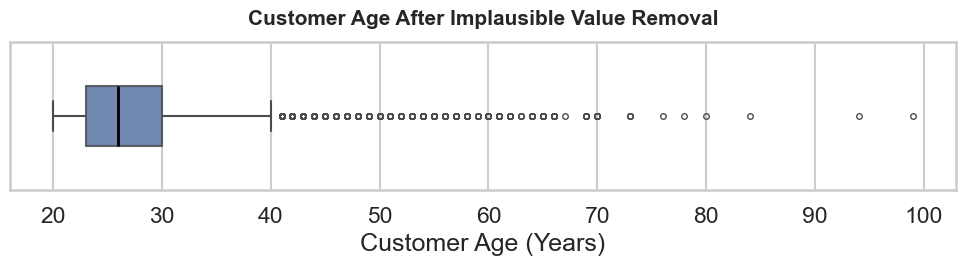

In [75]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=data['customer_age'],
    width=0.4,
    fliersize=4,
    linewidth=1.5,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

plt.title("Customer Age After Implausible Value Removal", fontsize=15, weight='bold', pad=12)
plt.xlabel("Customer Age (Years)")
plt.tight_layout()
plt.show()

##### customer_income

Customer income exhibits substantial right skew consistent with real-world earnings distributions. Rather than removing high-income observations, which represent legitimate population variability, a logarithmic transformation was applied to stabilize variance and improve model compatibility.

In [76]:
# Call the currency conversion function and correct the dataset
data['customer_income'] = currency_to_float(data['customer_income'])

# Now that we are in numerical form, we can analyze the series using the iqr_outliers function
iqr_outliers(data, 'customer_income')


,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,employment_duration_missing,loan_int_rate_missing,historical_default_missing
15,23,500000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,"£30,000.00",10.650000,10,NaN,3,NO DEFAULT,0,0,1
20,25,162500,RENT,2.0,VENTURE,A,"£35,000.00",7.490000,10,NaN,4,NO DEFAULT,0,0,1
33,25,306000,RENT,2.0,DEBTCONSOLIDATION,B,"£24,250.00",13.850000,10,NaN,3,NO DEFAULT,0,0,1
34,26,300000,MORTGAGE,10.0,MEDICAL,B,"£7,800.00",13.490000,6,NaN,4,NO DEFAULT,0,0,1
42,26,300000,MORTGAGE,10.0,VENTURE,A,"£20,000.00",7.880000,10,NaN,4,NO DEFAULT,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32549,58,780000,MORTGAGE,7.0,PERSONAL,A,"£4,500.00",6.910000,8,N,20,NO DEFAULT,0,0,0
32551,60,1900000,MORTGAGE,5.0,PERSONAL,A,"£1,500.00",11.011821,6,N,21,NO DEFAULT,0,1,0
32556,58,780000,MORTGAGE,7.0,PERSONAL,A,"£4,500.00",6.910000,8,NaN,19,NO DEFAULT,0,0,1
32567,61,160000,MORTGAGE,30.0,PERSONAL,B,"£24,000.00",10.380000,1,NaN,21,NO DEFAULT,0,0,1


In [77]:
# This is a check that the upper echelon of income earners are not outliers but rather the product of normally observed income stratification.
data['customer_income'].describe(percentiles=[.95, .99, .999])

count    3.256700e+04
mean     6.588524e+04
std      5.254102e+04
min      4.000000e+03
95%      1.380000e+05
99%      2.250000e+05
99.9%    6.412080e+05
max      2.039784e+06
Name: customer_income, dtype: float64

In [78]:
# Apply a log-normal transformation to heavy right-tailed data and save to new column
data['log_customer_income'] = np.log1p(data['customer_income'])

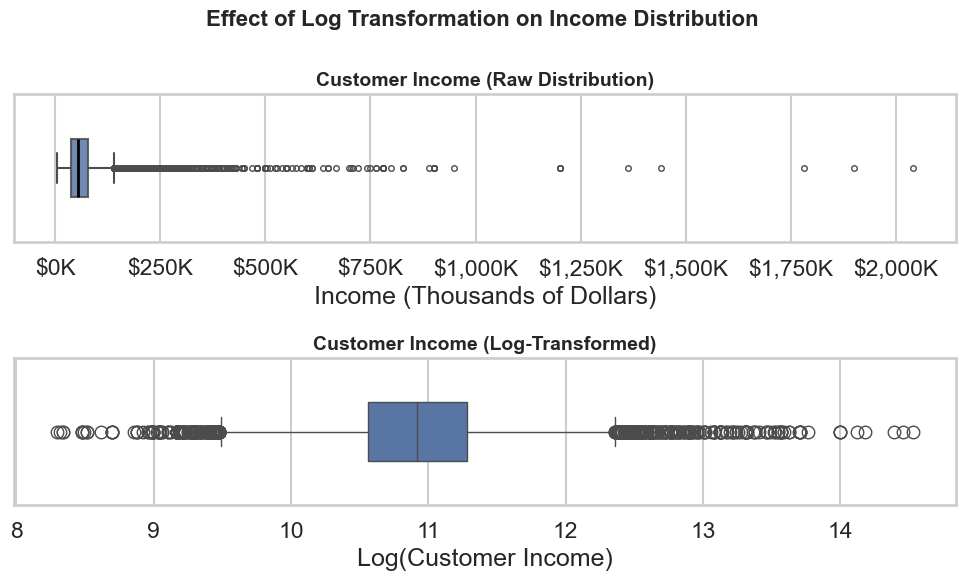

In [79]:

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 6),
    sharex=False
)

# -------------------------
# Raw income boxplot
# -------------------------
sns.boxplot(
    x=data['customer_income'],
    ax=axes[0],
    width=0.4,
    fliersize=4,
    linewidth=1.5,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

axes[0].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
)

axes[0].set_title(
    "Customer Income (Raw Distribution)",
    fontsize=14,
    weight='bold'
)
axes[0].set_xlabel("Income (Thousands of Dollars)")

# -------------------------
# Log income boxplot
# -------------------------
sns.boxplot(
    x=data['log_customer_income'],
    ax=axes[1],
    width=0.4
)

axes[1].set_title(
    "Customer Income (Log-Transformed)",
    fontsize=14,
    weight='bold'
)
axes[1].set_xlabel("Log(Customer Income)")

fig.suptitle(
    "Effect of Log Transformation on Income Distribution",
    fontsize=16,
    weight='bold'
)

plt.tight_layout()
plt.show()

##### employment_duration

One observation was identified as implausible, reflecting an employment tenure of 123 years. This record was removed as it likely represents a data entry error rather than a valid observation. The remaining outliers were retained because, although uncommon, they fall within a plausible range of employment durations. After cleaning, the distribution of this feature remains right-skewed.

In [80]:
# Function that reveals outliers 
tenure_outlier = iqr_outliers(data, 'employment_duration')
tenure_outlier['employment_duration'].max()

# Drop the most implausible data points. 
data = data[data['employment_duration'] <= 100]


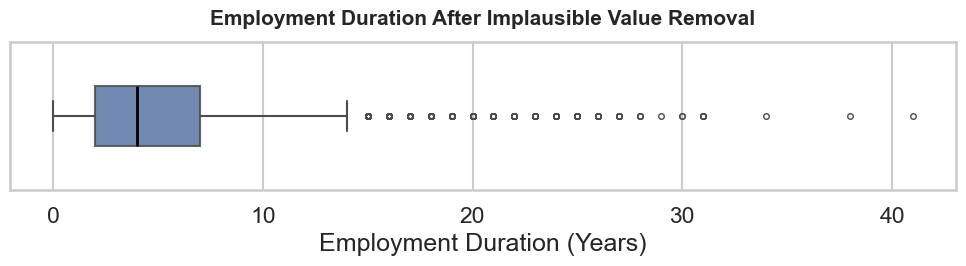

In [37]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=data['employment_duration'],
    width=0.4,
    fliersize=4,
    linewidth=1.5,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

plt.title("Employment Duration After Implausible Value Removal", fontsize=15, weight='bold', pad=12)
plt.xlabel("Employment Duration (Years)")
plt.tight_layout()
plt.show()

##### loan_intent

In [38]:
# The only objects I wanted to modify were the column values.  This is purely an aesthetic choice so that if I should need to visualize this feature the labeling will flow through nicely.  

intent_replace = {
    'EDUCATION':'Education',
    'MEDICAL':'Medical',
    'VENTURE':'Venture',
    'PERSONAL':'Personal',
    'DEBTCONSOLIDATION':'Debt Consolidation',
    'HOMEIMPROVEMENT':'Home Improvement',
}

data['loan_intent'].replace(intent_replace)

1               Education
2                 Medical
3                 Medical
4                 Medical
5                 Venture
               ...       
32581            Personal
32582            Personal
32583    Home Improvement
32584            Personal
32585             Medical
Name: loan_intent, Length: 32565, dtype: str

##### loan_amnt

Formal outlier tests such as Grubbs’ test were considered but ultimately rejected due to violations of normality assumptions and evidence suggesting mixed data-generating processes. Instead, distributional diagnostics using log-transformed values and percentile gap analysis were conducted to evaluate extreme observations.

This analysis revealed two loan amounts — 1,000,000 and 3,500,000 — that represent a substantial departure from the remainder of the distribution. To further investigate, an empirical cumulative distribution function (eCDF) plot was examined on a log₁₀ scale. The eCDF displayed a sharp vertical jump between the third and fifth orders of magnitude, and then a flat leveling off toward the right-most portion of the curve.  What is shown indicates a discontinuity inconsistent with the otherwise smooth distribution of loan values.

Such behavior suggests these observations likely originate from a different lending population, data entry irregularities, or an alternative product process rather than the same generating mechanism as the majority of records. Based on this evidence, these values were classified as noise rather than meaningful signal and were removed prior to downstream modeling.

In [39]:
# loan_amnt formatting needs to be adjusted into numeric from string for analysis. 
if not pd.api.types.is_numeric_dtype(data['loan_amnt']):
    data['loan_amnt'] = currency_to_float(data['loan_amnt'])

loan_amnt_outliers = iqr_outliers(data, 'loan_amnt')
loan_outlier_min = loan_amnt_outliers['loan_amnt'].min(); print(f'Outlier Min: {loan_outlier_min}')
loan_outlier_max = loan_amnt_outliers['loan_amnt'].max(); print(f'Outlier Max: {loan_outlier_max}')

Outlier Min: 23050.0
Outlier Max: 3500000.0


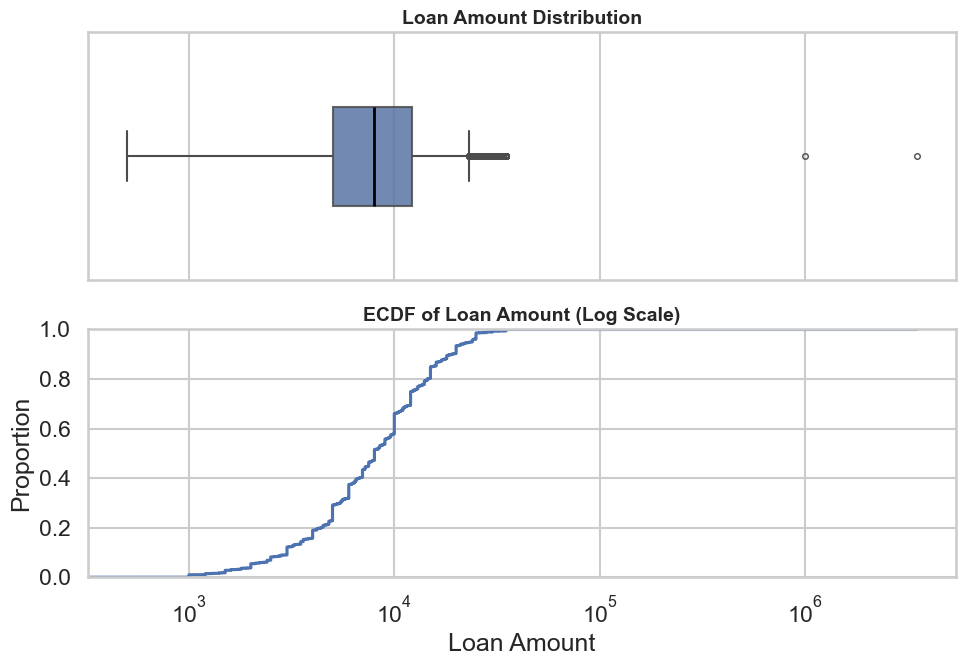

In [40]:
# The outliers were very spread apart.  On the top boxplot take note of the two datapoints deep into the right skew.  Given the context of this being financial data, I ran a eCDF plot to infer on tail behavior.  
# Create stacked subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 7),
    sharex=True   # keeps x-axis aligned (very useful here)
)

# --- Boxplot ---
sns.boxplot(
    x=data['loan_amnt'],
    ax=axes[0],
    width=0.4,
    fliersize=4,
    linewidth=1.5,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

axes[0].set_title("Loan Amount Distribution", fontsize=14, weight='bold')
axes[0].set_xlabel("")

# --- ECDF ---
sns.ecdfplot(
    data['loan_amnt'],
    ax=axes[1]
)

axes[1].set_xscale('log')
axes[1].set_title("ECDF of Loan Amount (Log Scale)", fontsize=14, weight='bold')
axes[1].set_xlabel("Loan Amount")

plt.tight_layout()
plt.show()

In [41]:
# Drop the outliers from the dataset
data = data[data['loan_amnt'] < 900000]

##### loan_int_rate

Outliers detected via IQR were retained because:
- values fall within realistic lending ranges
- represent <0.3% of observations
- likely reflect legitimate high-risk loans

In [42]:
loan_int_rate_outlier = iqr_outliers(data, 'loan_int_rate')
rates = loan_int_rate_outlier['loan_int_rate']

# Seventy obervations so I created a bin/count to display them.
bins = np.arange(20.0, rates.max() + 0.5, 0.5)
binned_rates = pd.cut(rates, bins=bins)
binned_counts = binned_rates.value_counts().sort_index()
print(binned_counts)


loan_int_rate
(20.0, 20.5]    25
(20.5, 21.0]    20
(21.0, 21.5]    13
(21.5, 22.0]     6
(22.0, 22.5]     5
(22.5, 23.0]     0
(23.0, 23.5]     1
Name: count, dtype: int64


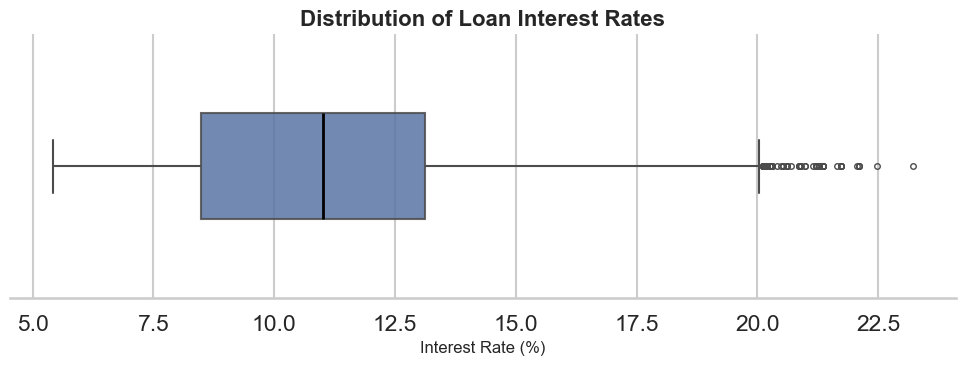

In [43]:

plt.figure(figsize=(10, 4))

# --- Boxplot ---
sns.boxplot(
    x=data['loan_int_rate'],
    width=0.4,
    fliersize=4,           # smaller outlier dots
    linewidth=1.5,
    boxprops=dict(alpha=0.85),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# --- Labels & title ---
plt.title("Distribution of Loan Interest Rates", fontsize=16, weight='bold')
plt.xlabel("Interest Rate (%)", fontsize=12)
plt.ylabel("")

# Remove unnecessary spines
sns.despine(left=True)

plt.tight_layout()
plt.show()
# RESULT:  No abnormal interest rates detected. 

##### cred_hist_length

We will keep the values as-is in the dataset.  None of the outliers are implausible and within a tolerant levels.  As would be expected, the credit history values mirror typical natural phenomena like life expectencies.  

<Axes: xlabel='cred_hist_length'>

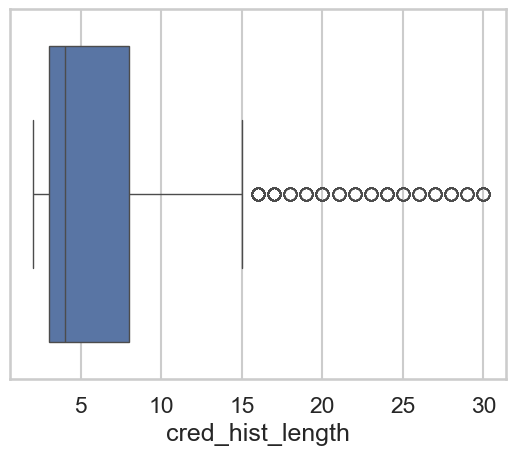

In [44]:
# Checked unique values
data['cred_hist_length'].value_counts()

# Checked against my IQR function.  Outliers were present according to holistic measures. 
iqr_outliers(data, 'cred_hist_length')

# Check boxplot to see distribution nothing that none of the values look implausible.  
sns.boxplot(x=data['cred_hist_length'])

#### Encoding categoricals

In [45]:
# Encode our dependent variable
data["default_flag"] = data["Current_loan_status"].map({
    "DEFAULT": 1,
    "NO DEFAULT": 0
})


# Encode missing as its own state
# I do not want to toss this column completely until I have justifiable reasoning for doing so.  
# Instead, I encoded it into separate buckets for analysis downstream. 1-previously defaulted, 0-no prior default, -1-no history/unknown. 
data['historical_default'] = (
    data['historical_default']
        .map({'Y': 1, 'N': 0})
        .fillna(-1)
        .astype(int)
)

# This encodes the loan_grade series.  I will require this to produce feature engineering downstream. 

# Map the grades to codes
grade_map = {
    "A": 1,
    "B": 2,
    "C": 3,
    "D": 4,
    "E": 5,
    "F": 6,
    "G": 7
}
# Overwrite grades with codes
data["loan_grade"] = data["loan_grade"].map(grade_map)
# Sanity check to make sure there were no grades missed. 
data["loan_grade"].isna().sum()



np.int64(0)

#### Feature creation:

Feature Engineering Rationale

Additional features were constructed to better represent borrower
affordability, financial experience, and employment stability.
These transformations reflect common credit-risk underwriting metrics.

In [46]:
# Income-to-loan ratio
# Higher ratios indicate safer borrowers.  Lower ratios indicate riskier borrowers. 
data["income_loan_ratio"] = data["customer_income"] / data["loan_amnt"]

In [47]:
# Loan Burden
# This is synonymous to Debt-to-Income calculations. 
data["loan_percent_income"] = data["loan_amnt"] / data["customer_income"]

In [48]:
# Employment stability metric
# Longer employment tenure, smaller the risk for default
data["employment_years"] = data["employment_duration"] / 12

In [49]:
# Credit Experience vs Age metric
data["credit_age_ratio"] = data["cred_hist_length"] / data["customer_age"]

In [50]:
# Interaction effect of Interest Rate vs loan grade. 
data["rate_per_grade"] = data["loan_int_rate"] / data["loan_grade"]

## Exploratory Data Analysis

In [89]:
# DELETE AFTER
data.columns

Index(['customer_age', 'customer_income', 'home_ownership',
       'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length',
       'Current_loan_status', 'employment_duration_missing',
       'loan_int_rate_missing', 'historical_default_missing',
       'log_customer_income'],
      dtype='str')

##### Univariate Analysis

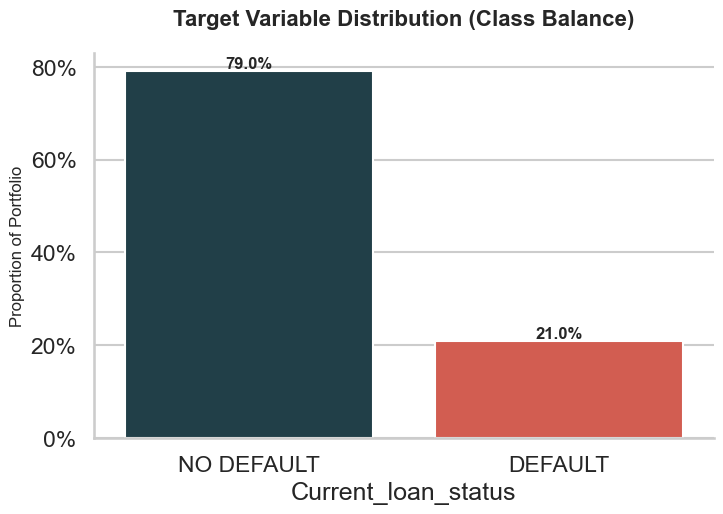

In [ ]:
# The Target Variable:  Current_loan_status
plot_target_distribution(data, 'Current_loan_status')

###### Categorical & Ordinal Features

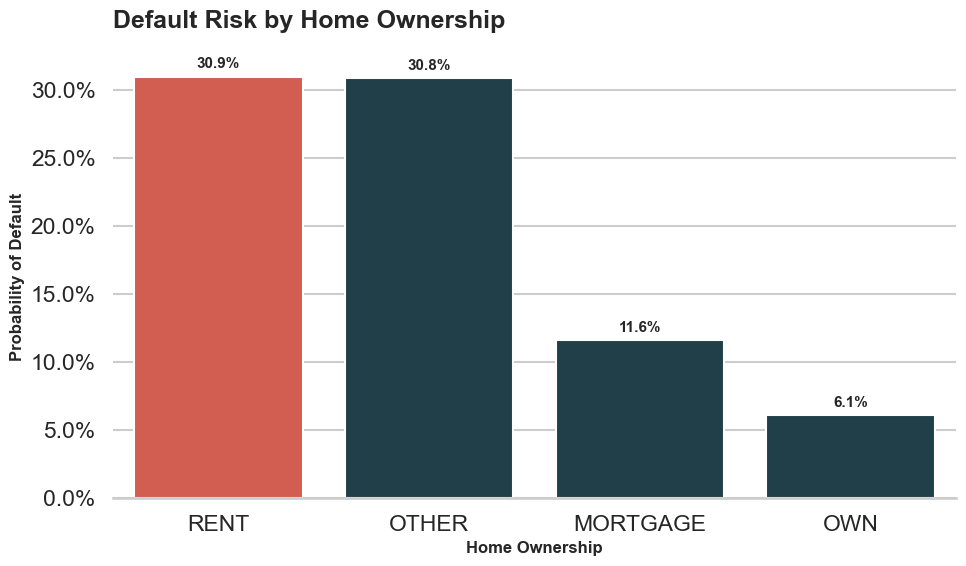

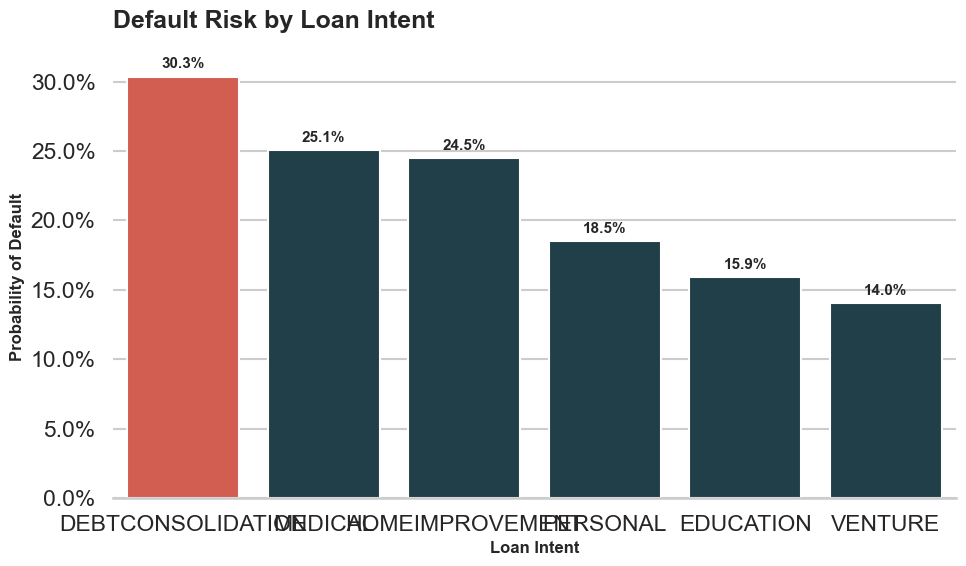

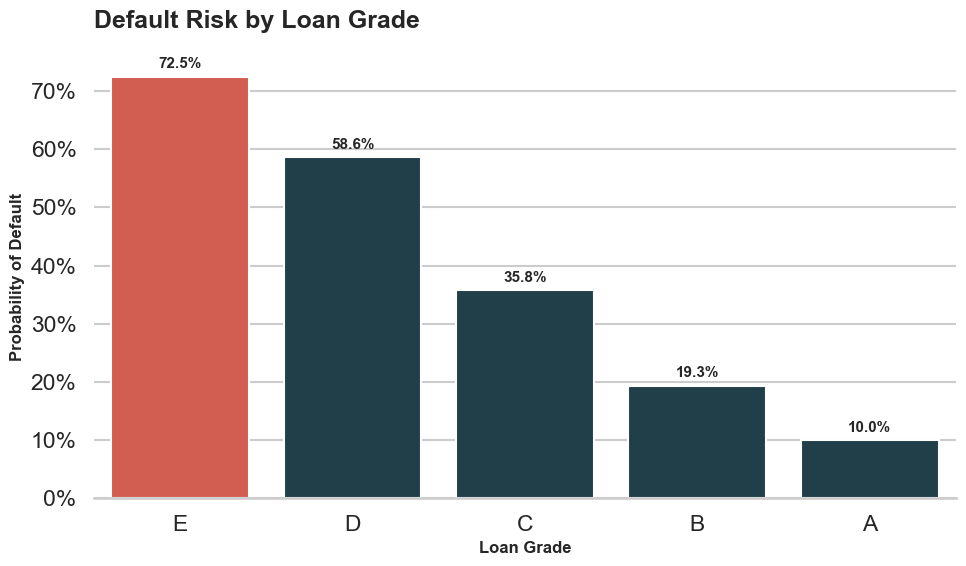

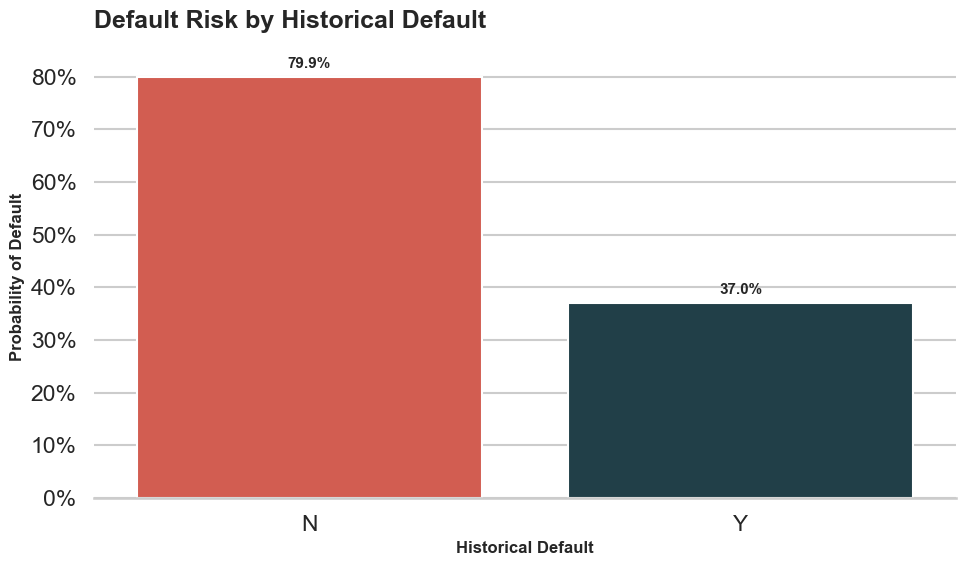

In [99]:
plot_professional_default_rate(data, "home_ownership")
plot_professional_default_rate(data, "loan_intent")
plot_professional_default_rate(data, "loan_grade")
plot_professional_default_rate(data, "historical_default")


###### Continuous Financials

In [ ]:
plot_professional_default_rate(data, "customer_income")
plot_professional_default_rate(data, "loan_amnt")
plot_professional_default_rate(data, "loan_int_rate")
plot_professional_default_rate(data, "loan_percent_income")

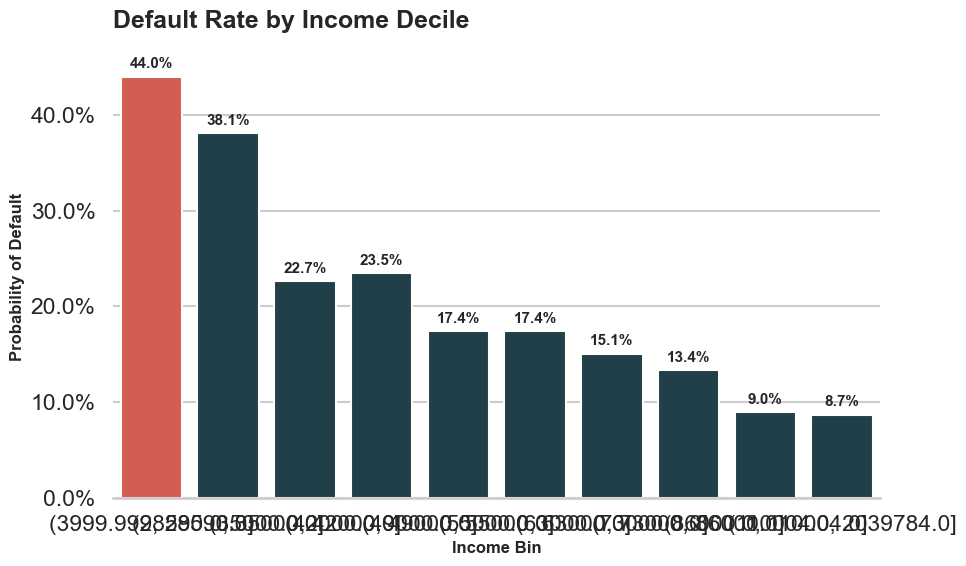

NameError: name 'plot_univariate_continuous' is not defined

In [ ]:
# Example for Income
data['income_bin'] = pd.qcut(data['customer_income'], q=10, duplicates='drop')
plot_professional_default_rate(data, 'income_bin', title="Default Rate by Income Decile")

cont_features = ['customer_income', 'loan_amnt', 'loan_int_rate']

for col in cont_features:
    # Use the Histogram/Boxplot combo function here
    plot_univariate_continuous(data, col, f"Distribution of {col.replace('_', ' ').title()}")

###### Discrete Features

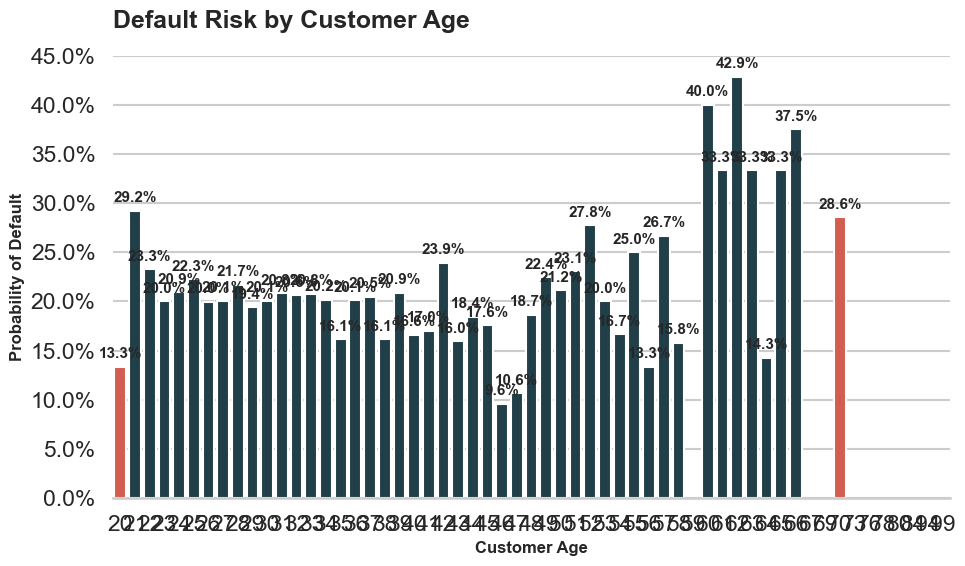

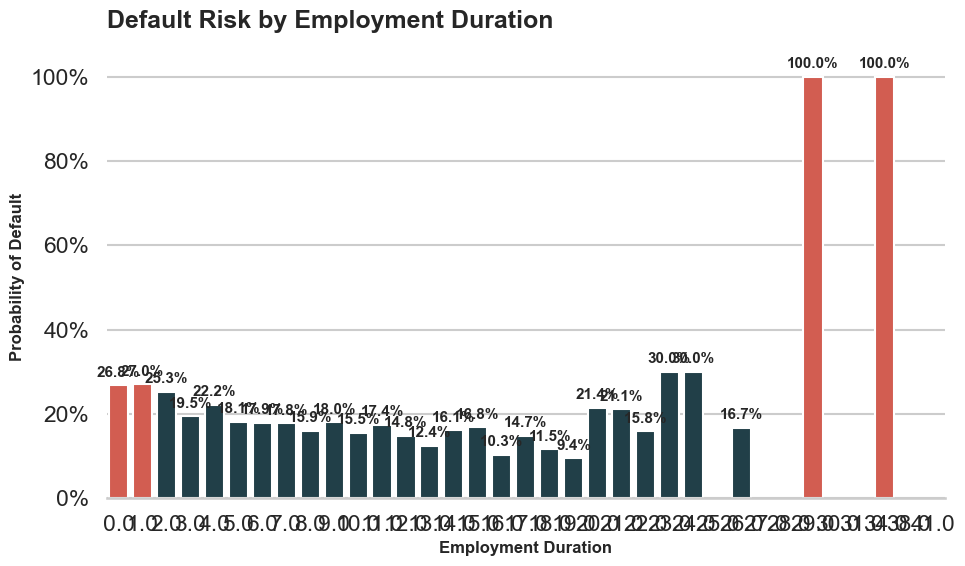

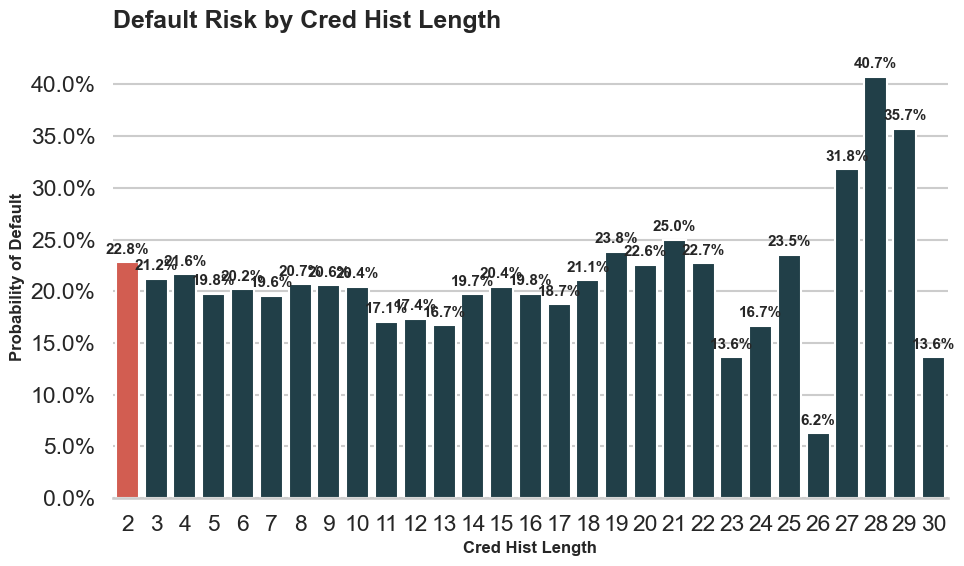

In [102]:
plot_professional_default_rate(data, "customer_age")
plot_professional_default_rate(data, "employment_duration")
plot_professional_default_rate(data, "cred_hist_length")


##### Bivariate Analysis

##### Multivariate Analysis

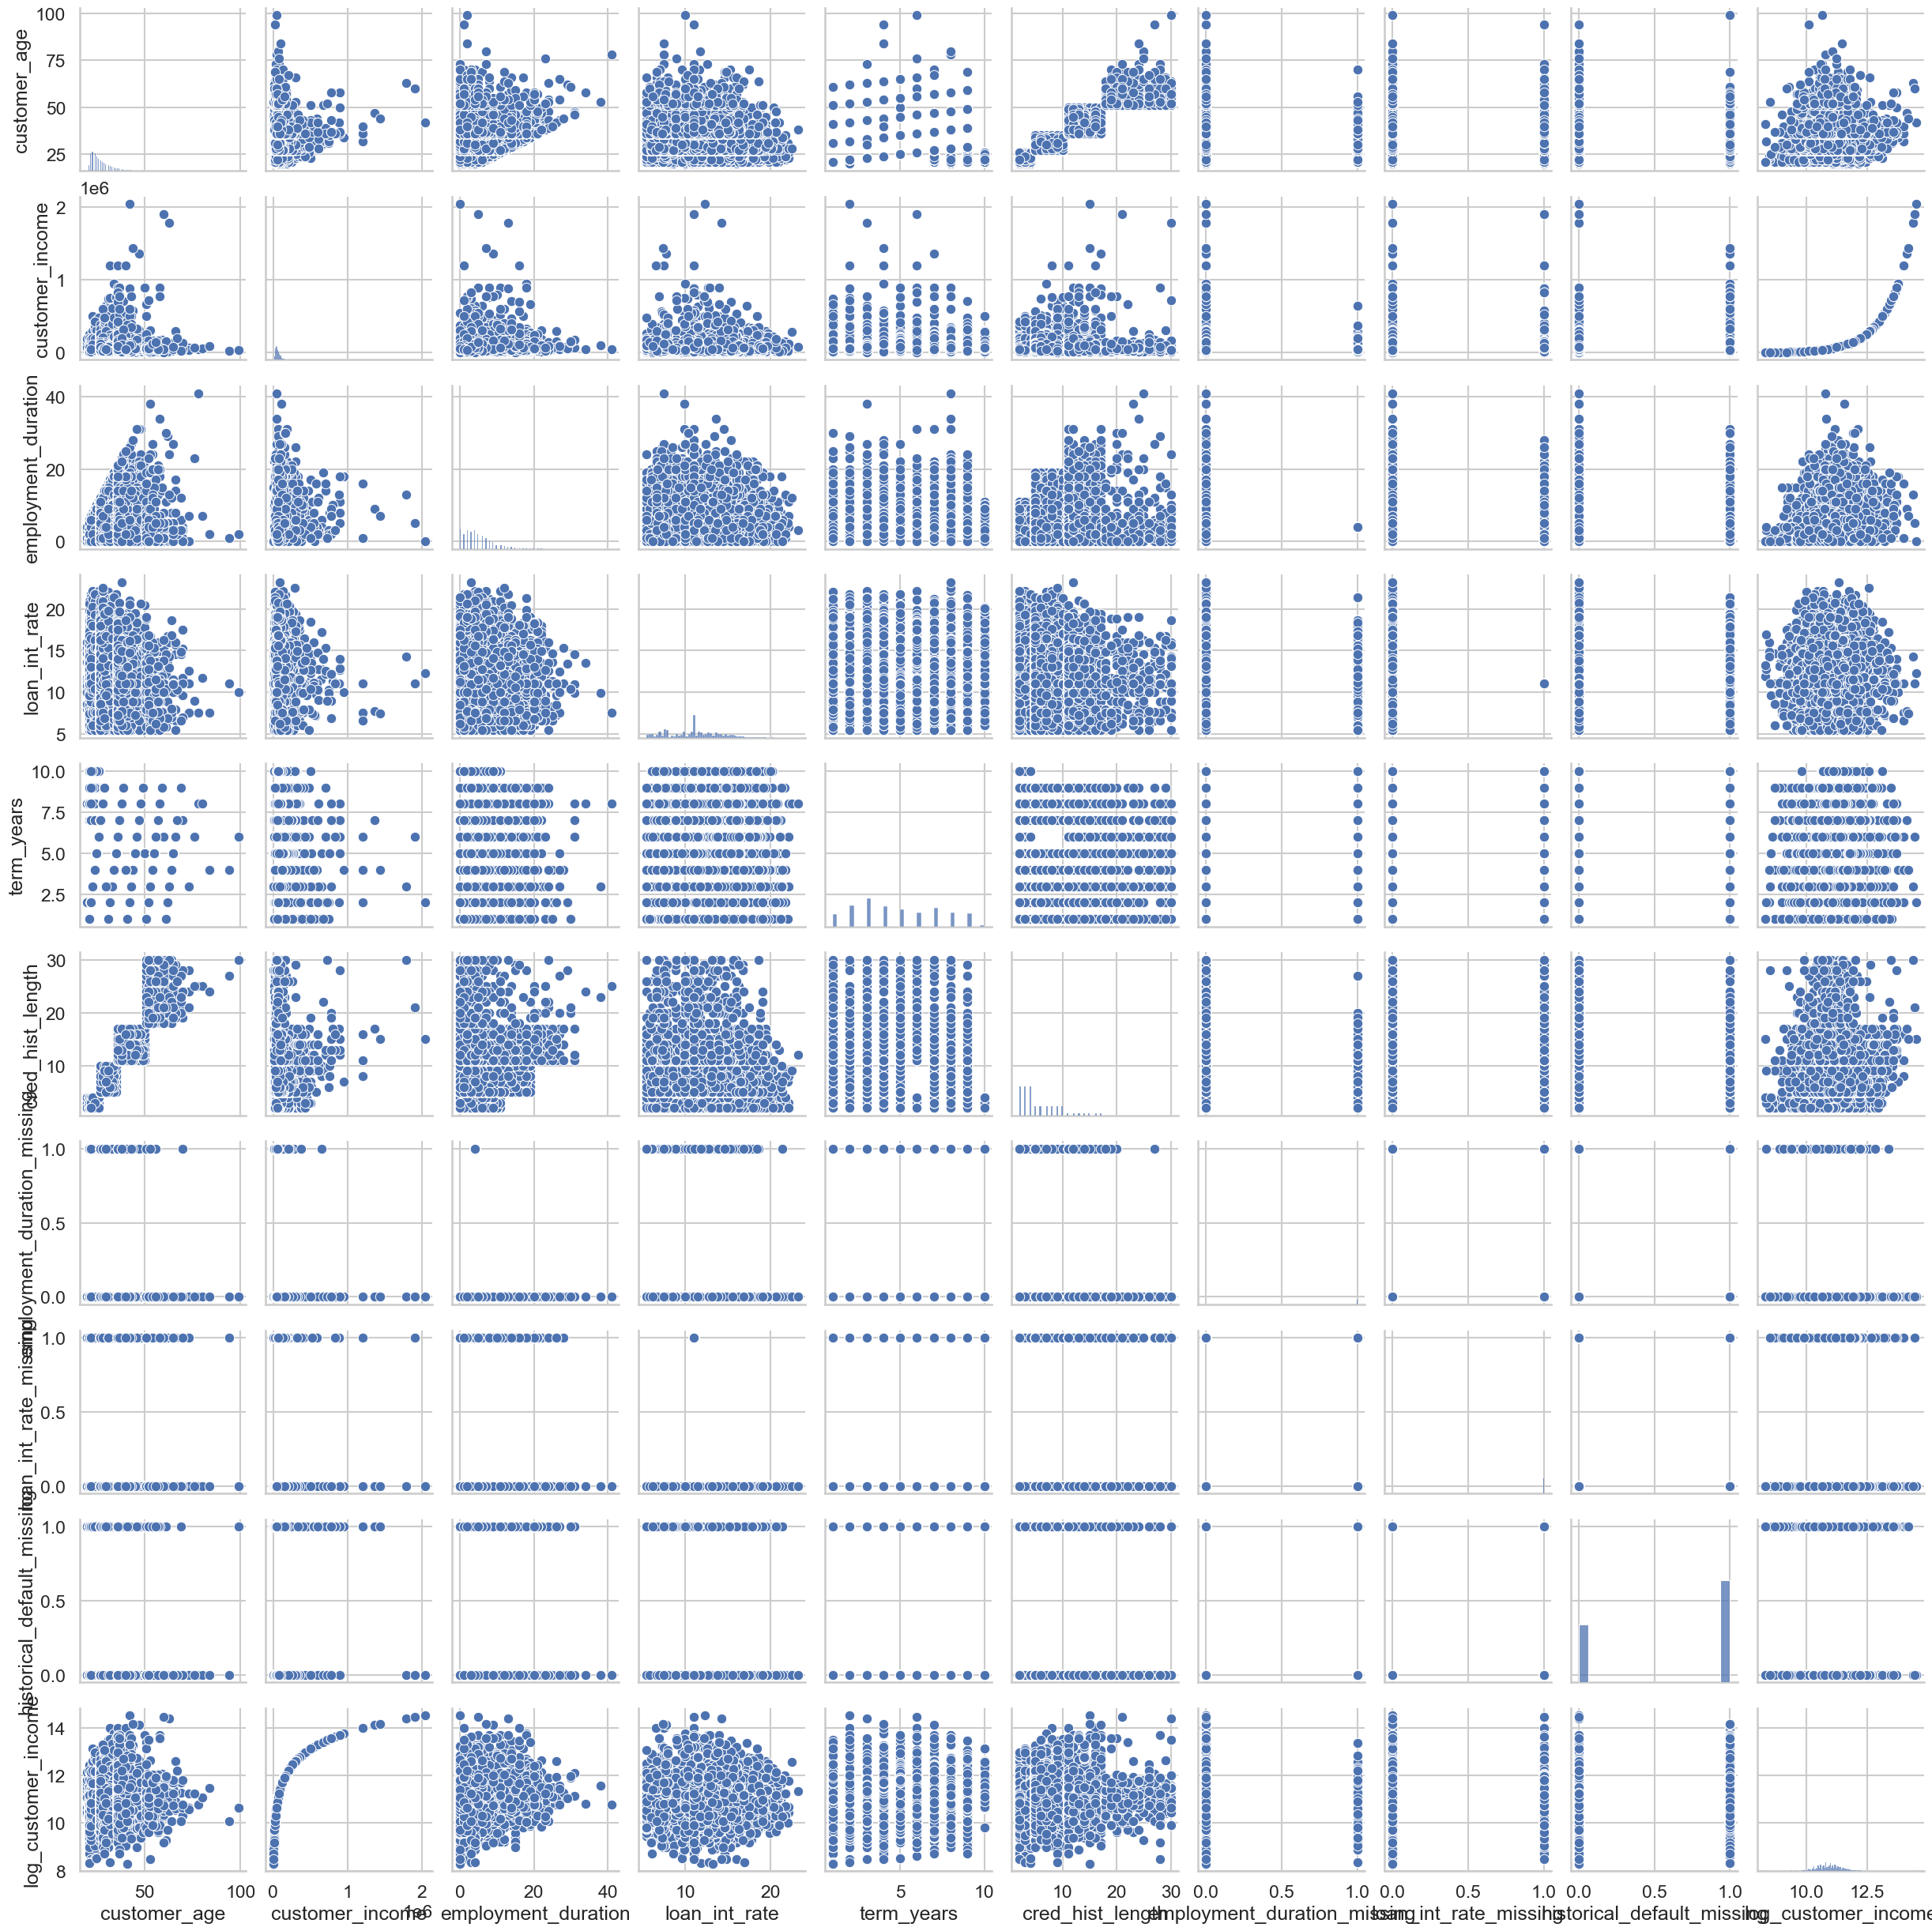

In [88]:
sns.pairplot(data)

##### Target Understanding of Baseline Risk

In [51]:
# Compute baseline default rates.
default_rate = data["default_flag"].mean()
print(f"Overall Default Rate: {default_rate:.2%}")

Overall Default Rate: 20.98%


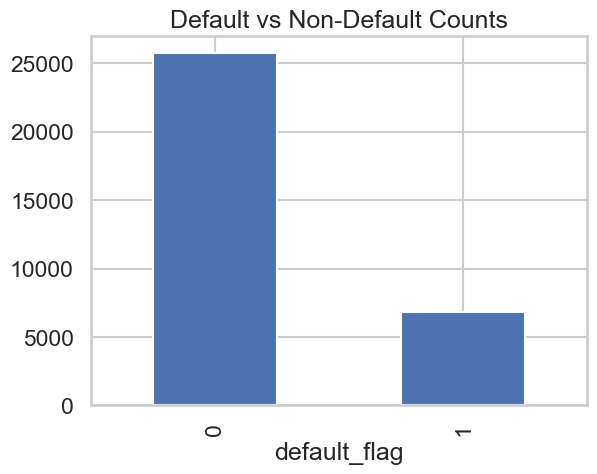

In [52]:
data["default_flag"].value_counts().plot(kind="bar")
plt.title("Default vs Non-Default Counts")
plt.show()

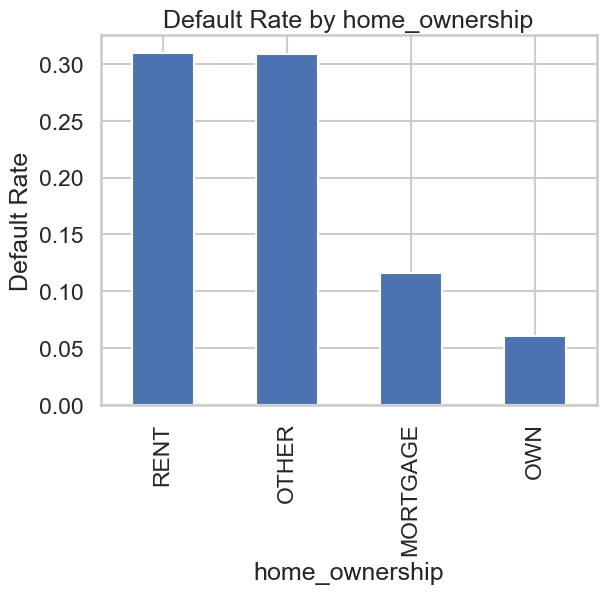

home_ownership
RENT        0.309462
OTHER       0.308411
MORTGAGE    0.115791
OWN         0.060782
Name: default_flag, dtype: float64

In [53]:
default_rate_by_feature(data, "home_ownership")

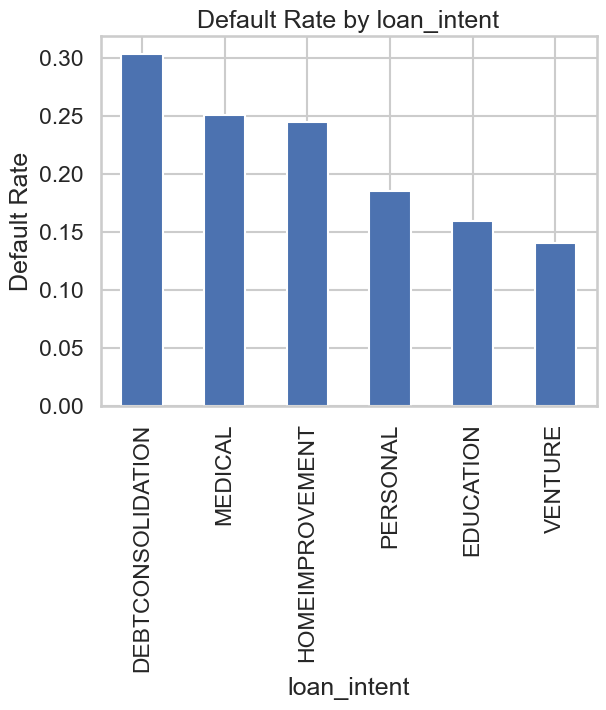

loan_intent
DEBTCONSOLIDATION    0.303455
MEDICAL              0.250618
HOMEIMPROVEMENT      0.244660
PERSONAL             0.184917
EDUCATION            0.159094
VENTURE              0.140357
Name: default_flag, dtype: float64

In [54]:
default_rate_by_feature(data, "loan_intent")

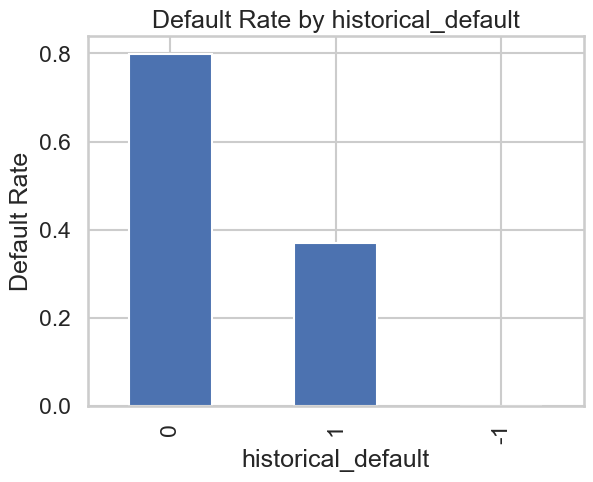

historical_default
 0    0.799404
 1    0.370449
-1    0.000000
Name: default_flag, dtype: float64

In [55]:
default_rate_by_feature(data, "historical_default")

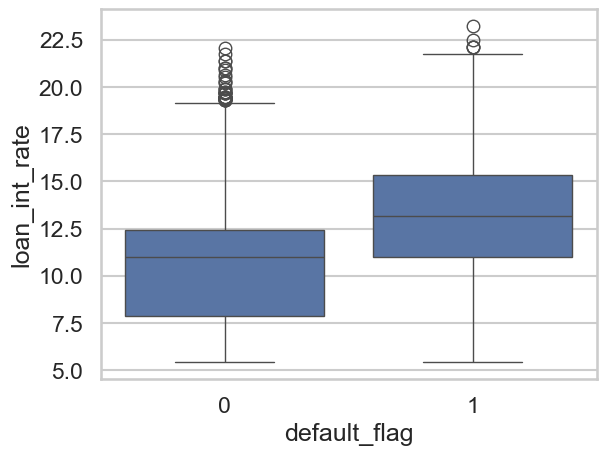

In [56]:
sns.boxplot(x="default_flag", y="loan_int_rate", data=data)
plt.show()

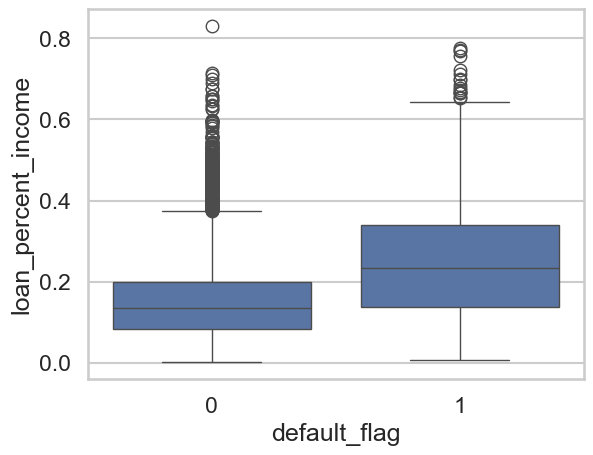

In [57]:
sns.boxplot(
    x="default_flag",
    y="loan_percent_income",
    data=data
)
plt.show()

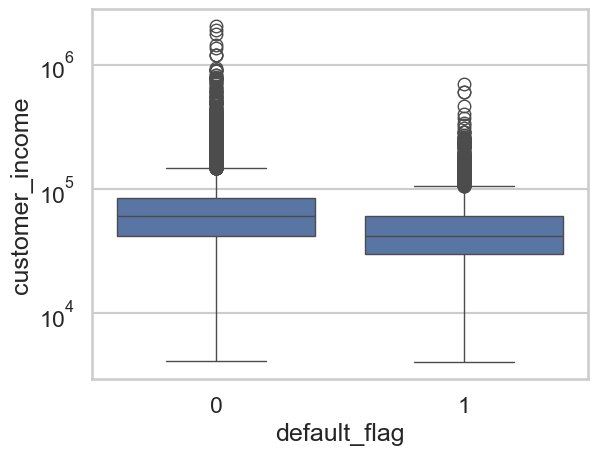

In [58]:
sns.boxplot(x="default_flag", y="customer_income", data=data)
plt.yscale("log")
plt.show()

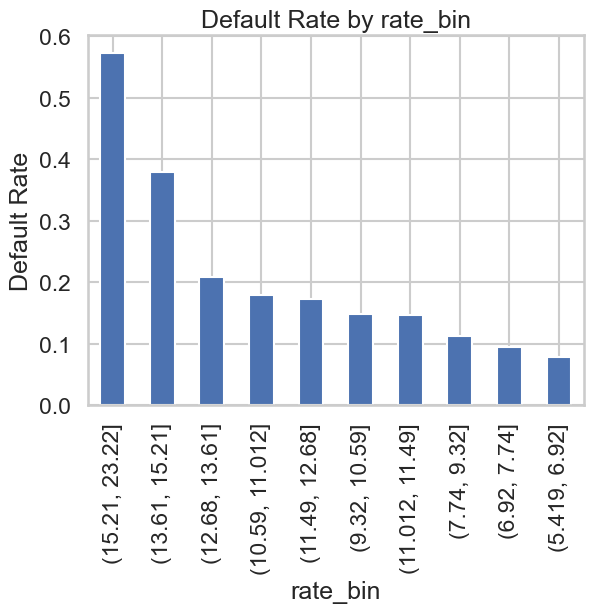

rate_bin
(15.21, 23.22]     0.573141
(13.61, 15.21]     0.378558
(12.68, 13.61]     0.208500
(10.59, 11.012]    0.178829
(11.49, 12.68]     0.172836
(9.32, 10.59]      0.147699
(11.012, 11.49]    0.146976
(7.74, 9.32]       0.112053
(6.92, 7.74]       0.093910
(5.419, 6.92]      0.078281
Name: default_flag, dtype: float64

In [59]:
data["rate_bin"] = pd.qcut(data["loan_int_rate"], 10)

default_rate_by_feature(data, "rate_bin")

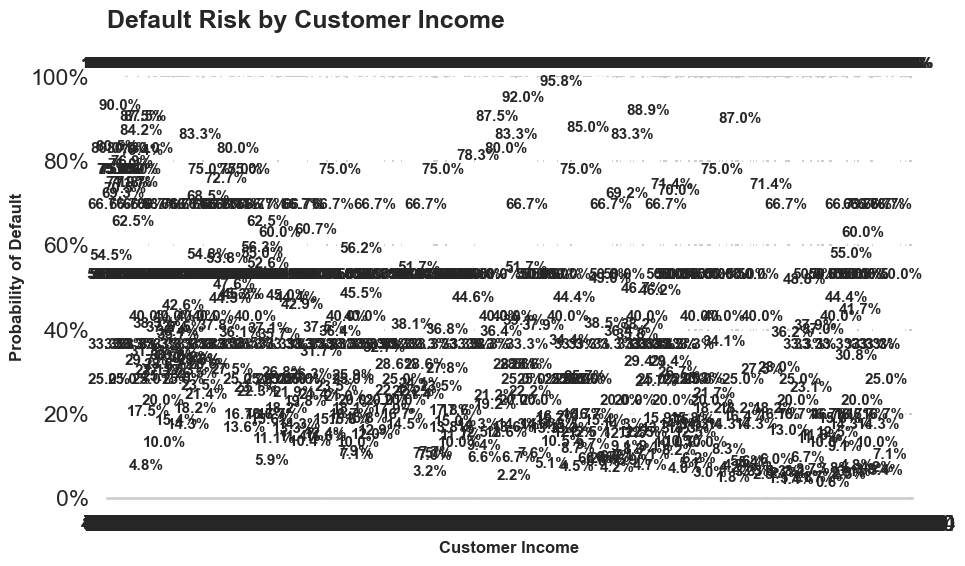

In [140]:
import matplotlib.ticker as mtick

def plot_professional_default_rate(df, feature, title=None):
    # Calculate rates
    summary = df.groupby(feature)["Current_loan_status"].value_counts(normalize=True).unstack()["DEFAULT"]
    summary = summary.sort_values(ascending=False)
    
    # 1. Setup Figure
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
    
    # 2. Use a sophisticated color palette (e.g., 'mako' or custom hex)
    colors = ['#1a434e' if (x < summary.max()) else '#e74c3c' for x in summary]
    
    sns.barplot(x=summary.index, y=summary.values, palette=colors, ax=ax)
    
    # 3. Enhance Typography and Labels
    ax.set_title(title or f"Default Risk by {feature.replace('_', ' ').title()}", 
                 fontsize=18, pad=20, fontweight='bold', loc='left')
    ax.set_ylabel("Probability of Default", fontsize=12, fontweight='bold')
    ax.set_xlabel(feature.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    # 4. Format Y-axis as Percentage
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # 5. Remove "Chart Junk" (Spines)
    sns.despine(left=True, bottom=False)
    
    # 6. Add Data Labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1%}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_professional_default_rate(data, 'customer_income', title=None)

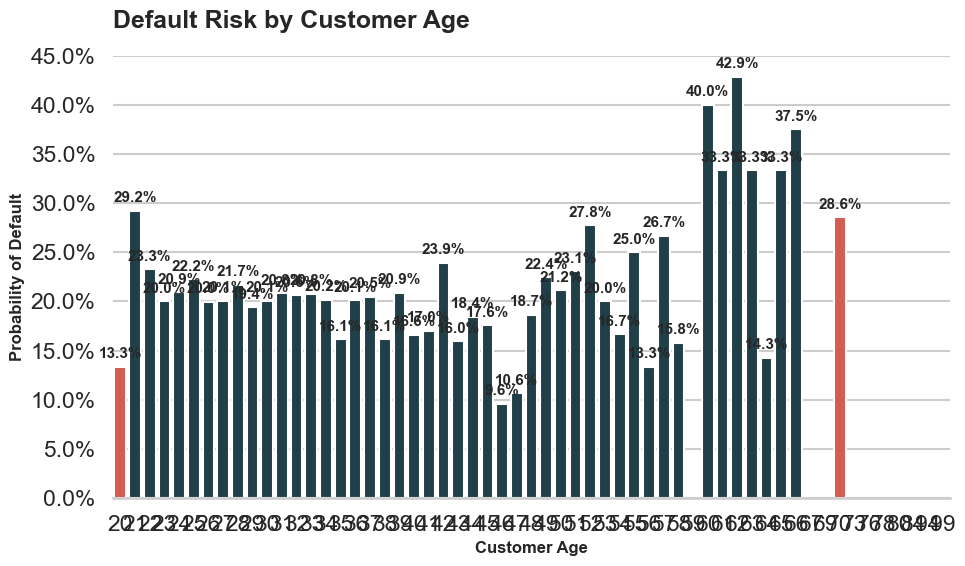

In [141]:
plot_professional_default_rate(data, 'customer_age', title=None)

In [139]:
data.columns

Index(['customer_age', 'customer_income', 'home_ownership',
       'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length',
       'Current_loan_status', 'employment_duration_missing',
       'loan_int_rate_missing', 'historical_default_missing',
       'log_customer_income', 'default_flag', 'income_loan_ratio',
       'loan_percent_income', 'employment_years', 'credit_age_ratio',
       'rate_per_grade', 'rate_bin'],
      dtype='str')

##### Univariate Risk Analysis

##### Affordability & Financial Stress Analysis

##### Credit history & Behavior Signals

##### Interaction Exploration

##### Data Quality Checks for Modeling

##### Hypothesis Summary

## Modeling Pipeline

Train/test split

Preprocessing pipeline

Multiple models

## Model Evaluation

Compare models

Select champion

## Model Interpretation

Key drivers of default

Explain results clearly

## Business Recommendations

Risk segments

Lending strategy suggestions

## Conclusion

Limitations

Future improvements